# 04 — Evaluation Suite & Probability Calibration
### Lending Club Accepted Loans — Credit Risk (Default Prediction)

Two questions this notebook answers, and they're genuinely different questions:

1. **Does the model rank-order risk well?** (discrimination — ROC/PR-AUC, KS, Gini,
   decile/lift tables)
2. **Are the predicted probabilities themselves trustworthy numbers?** (calibration —
   reliability diagrams, Brier score)

A model can be excellent at (1) and useless at (2), especially after the class
weighting from notebook 03 — which is exactly the situation here, and exactly why this
notebook exists as a separate step rather than a couple of extra cells tacked onto
modeling.

We finish by turning a score into a business decision: choosing an accept/decline
cutoff from an actual cost trade-off, not from a generic 0.5 default or a pure
F1-maximization that ignores what the two error types actually cost.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv('train.csv')
val_df = pd.read_csv('val.csv')
test_df = pd.read_csv('test.csv')

TARGET = 'bad_flag'
feature_cols = [c for c in train_df.columns if c != TARGET]
X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_val, y_val = val_df[feature_cols], val_df[TARGET]
X_test, y_test = test_df[feature_cols], test_df[TARGET]

preprocess = joblib.load('preprocess.joblib')
raw_model = joblib.load('xgb_raw_model.joblib')

X_val_enc = preprocess.transform(X_val)
X_test_enc = preprocess.transform(X_test)

p_val_raw = raw_model.predict_proba(X_val_enc)[:, 1]
p_test_raw = raw_model.predict_proba(X_test_enc)[:, 1]

## 1. Discrimination metrics

`Gini = 2 * AUC - 1` shows up constantly in credit-scoring literature and vendor score
documentation (FICO, bureau scores) in place of raw AUC — same information, rescaled so
a random model reads 0 and a perfect model reads 1.

In [2]:
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score, precision_recall_curve

auc_val = roc_auc_score(y_val, p_val_raw)
print(f"Validation ROC-AUC: {auc_val:.4f}   Gini: {2*auc_val-1:.4f}")
print(f"Validation PR-AUC:  {average_precision_score(y_val, p_val_raw):.4f}"
      f"   (no-skill baseline = bad rate = {y_val.mean():.4f})")

Validation ROC-AUC: 0.7038   Gini: 0.4076
Validation PR-AUC:  0.2811   (no-skill baseline = bad rate = 0.1474)


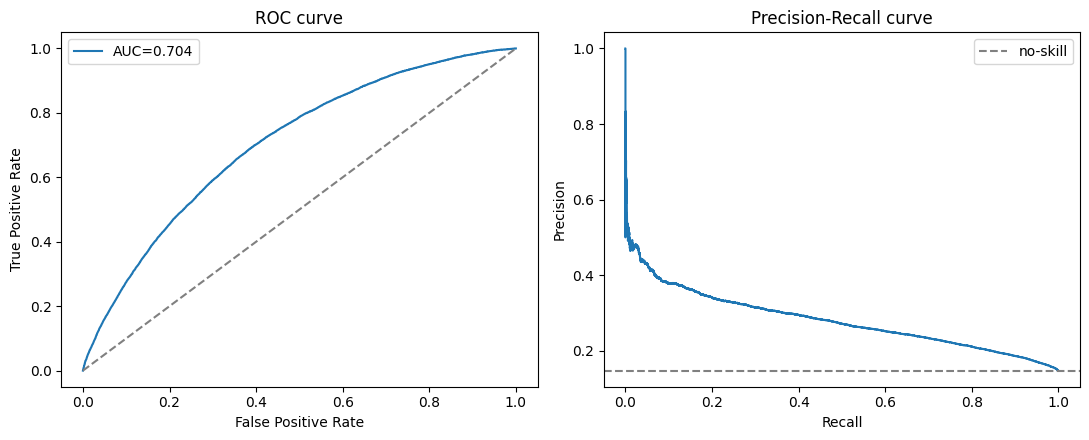

In [3]:
fpr, tpr, _ = roc_curve(y_val, p_val_raw)
prec, rec, _ = precision_recall_curve(y_val, p_val_raw)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, label=f'AUC={auc_val:.3f}')
axes[0].plot([0,1],[0,1],'--',color='gray')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curve'); axes[0].legend()

axes[1].plot(rec, prec)
axes[1].axhline(y_val.mean(), color='gray', linestyle='--', label='no-skill')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve'); axes[1].legend()
plt.tight_layout()
plt.show()

## 2. KS statistic — the credit-risk-standard separation metric

The Kolmogorov-Smirnov statistic here is the maximum vertical gap between the
cumulative distribution of scores for goods vs. bads. It answers "at the single best
cutoff, how separated are the two populations?" — a natural complement to AUC (which
integrates separation across *every* possible cutoff). 

KS statistic: 0.3034  (p-value: 0.00e+00)


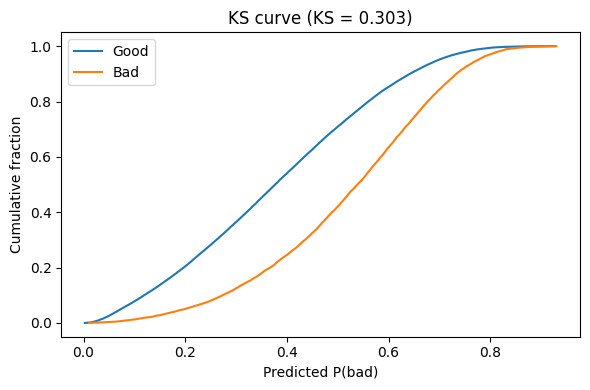

In [4]:
from scipy.stats import ks_2samp

ks_result = ks_2samp(p_val_raw[y_val == 0], p_val_raw[y_val == 1])
print(f"KS statistic: {ks_result.statistic:.4f}  (p-value: {ks_result.pvalue:.2e})")

fig, ax = plt.subplots(figsize=(6,4))
for label, name in [(0, 'Good'), (1, 'Bad')]:
    scores = np.sort(p_val_raw[y_val == label])
    cum = np.arange(1, len(scores)+1) / len(scores)
    ax.plot(scores, cum, label=name)
ax.set_xlabel('Predicted P(bad)'); ax.set_ylabel('Cumulative fraction')
ax.set_title(f'KS curve (KS = {ks_result.statistic:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

As a rough industry benchmark, KS in the 0.3-0.5 range is typical for a decent
retail-credit scorecard; below ~0.2 usually means the model isn't separating risk well
enough to be operationally useful, and above ~0.7 is unusual enough to be worth
double-checking for leakage.

## 3. Decile (rank-ordering) and lift tables

Split applicants into deciles by score, and check that the observed bad rate climbs
(ideally close to monotonically) from the safest to the riskiest decile. A
non-monotonic decile table is a bigger red flag in practice than a mediocre AUC —
it means the model's ranking breaks down in some part of the score range, which
directly undermines cutoff-based decisions.

In [5]:
def decile_table(y_true, y_score, n_bins=10):
    d = pd.DataFrame({'y': y_true, 'score': y_score})
    d['decile'] = pd.qcut(d['score'], n_bins, labels=False, duplicates='drop')
    tbl = d.groupby('decile').agg(n=('y', 'size'), bad=('y', 'sum'),
                                   avg_score=('score', 'mean'))
    tbl['bad_rate'] = tbl['bad'] / tbl['n']
    tbl = tbl.sort_index(ascending=False)  # highest-risk decile first
    tbl['cum_bad_pct'] = tbl['bad'].cumsum() / tbl['bad'].sum()
    tbl['cum_pop_pct'] = tbl['n'].cumsum() / tbl['n'].sum()
    tbl['lift'] = tbl['cum_bad_pct'] / tbl['cum_pop_pct']
    return tbl.round(4)

dt = decile_table(y_val.values, p_val_raw)
dt

,n,bad,avg_score,bad_rate,cum_bad_pct,cum_pop_pct,lift
decile,,,,,,,
9,9264,3084,0.7279,0.3329,0.2259,0.1,2.2583
8,9263,2377,0.6231,0.2566,0.3999,0.2,1.9996
7,9263,1853,0.5524,0.2000,0.5356,0.3,1.7854
6,9263,1660,0.4899,0.1792,0.6572,0.4,1.6430
5,9263,1300,0.4311,0.1403,0.7524,0.5,1.5048
4,9264,1051,0.3723,0.1134,0.8294,0.6,1.3823
3,9263,866,0.3128,0.0935,0.8928,0.7,1.2754
2,9263,676,0.2480,0.0730,0.9423,0.8,1.1779
1,9263,500,0.1740,0.0540,0.9789,0.9,1.0877


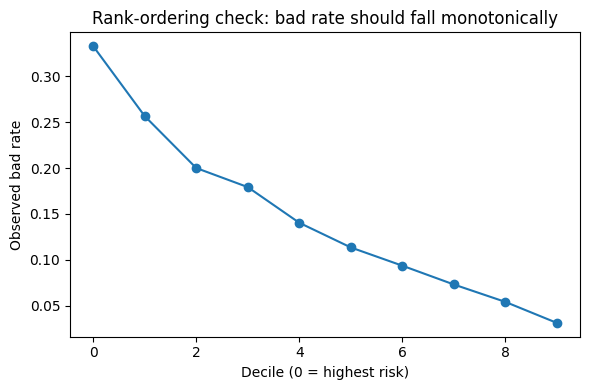

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(range(len(dt)), dt['bad_rate'].values, marker='o')
ax.set_xlabel('Decile (0 = highest risk)'); ax.set_ylabel('Observed bad rate')
ax.set_title('Rank-ordering check: bad rate should fall monotonically')
plt.tight_layout()
plt.show()

The `lift` column says how much better than random you'd do by acting on the riskiest
X% of applicants first — e.g. a lift of 2.0 at the 20% cumulative-population mark means
that group contains twice the bad loans you'd expect if risk were spread evenly. 

## 4. Calibration — is `predict_proba` actually a probability?

We already showed in notebook 03 that class weighting inflates the *average* predicted
probability. A reliability diagram makes this concrete across the whole score range: it
bins predictions and plots predicted probability against the *observed* bad rate in
each bin. A perfectly calibrated model sits on the diagonal.

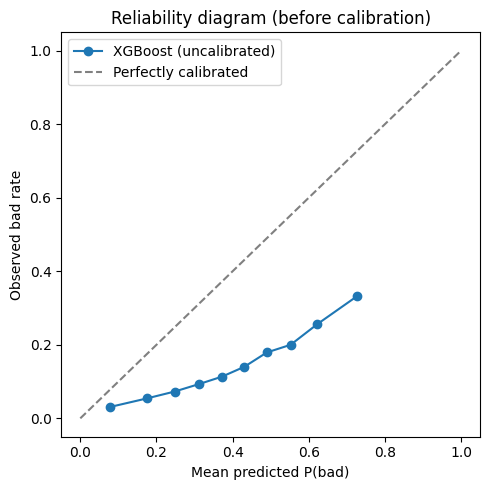

Brier score (uncalibrated): 0.19311705231666565


In [7]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

frac_pos, mean_pred = calibration_curve(y_val, p_val_raw, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(mean_pred, frac_pos, marker='o', label='XGBoost (uncalibrated)')
ax.plot([0,1],[0,1],'--',color='gray', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted P(bad)'); ax.set_ylabel('Observed bad rate')
ax.set_title('Reliability diagram (before calibration)')
ax.legend()
plt.tight_layout()
plt.show()

print('Brier score (uncalibrated):', brier_score_loss(y_val, p_val_raw))

## 5. Fixing it: `CalibratedClassifierCV`

We calibrate on the **validation set** (never seen during training) and keep the
**OOT test set** completely untouched until the very last cell, so the final numbers
reported there are honestly out-of-sample in every sense — not used for training,
tuning, *or* calibration.

In [8]:
from sklearn.calibration import CalibratedClassifierCV

try:
    from sklearn.frozen import FrozenEstimator
    calibrated_model = CalibratedClassifierCV(FrozenEstimator(raw_model), method='isotonic')
except ImportError:
    # scikit-learn < 1.6
    calibrated_model = CalibratedClassifierCV(raw_model, method='isotonic', cv='prefit')

calibrated_model.fit(X_val_enc, y_val)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","FrozenEstimat...ee=None, ...))"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List

**Isotonic vs. Platt (sigmoid) scaling** — isotonic regression is non-parametric and
more flexible, but it can overfit with a small calibration set; Platt scaling (a
1-D logistic regression on the raw score) is more constrained and more stable when
your calibration set is small (rough rule of thumb: prefer Platt below a few hundred to
~1,000 calibration examples, isotonic above that). Our validation set is large enough
here for isotonic to be the reasonable choice; on a smaller dataset, swap
`method='isotonic'` for `method='sigmoid'` and re-check the reliability diagram.

--- OOT test set: before vs. after calibration ---
ROC-AUC   before=0.7035  after=0.7030
Brier     before=0.1879  after=0.1180


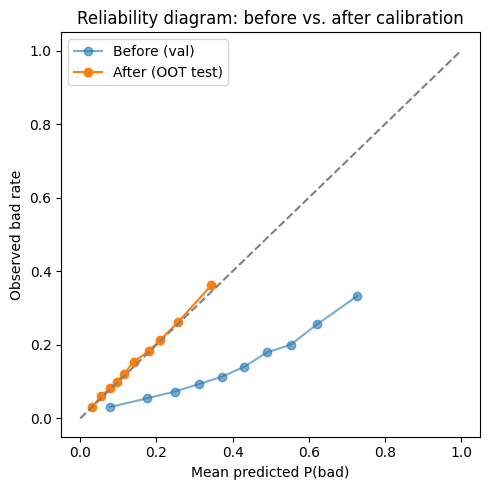

In [9]:
p_test_cal = calibrated_model.predict_proba(X_test_enc)[:, 1]

print('--- OOT test set: before vs. after calibration ---')
print(f"ROC-AUC   before={roc_auc_score(y_test, p_test_raw):.4f}  after={roc_auc_score(y_test, p_test_cal):.4f}")
print(f"Brier     before={brier_score_loss(y_test, p_test_raw):.4f}  after={brier_score_loss(y_test, p_test_cal):.4f}")

frac_pos_after, mean_pred_after = calibration_curve(y_test, p_test_cal, n_bins=10, strategy='quantile')
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(mean_pred, frac_pos, marker='o', label='Before (val)', alpha=0.6)
ax.plot(mean_pred_after, frac_pos_after, marker='o', label='After (OOT test)')
ax.plot([0,1],[0,1],'--',color='gray')
ax.legend(); ax.set_xlabel('Mean predicted P(bad)'); ax.set_ylabel('Observed bad rate')
ax.set_title('Reliability diagram: before vs. after calibration')
plt.tight_layout()
plt.show()

Notice ROC-AUC barely moves — **calibration doesn't change the ranking, only the
scale**, which is exactly the point: it fixes what the numbers *mean* without touching
what the model is good at. Brier score (a combined discrimination+calibration score,
lower is better) should drop noticeably.

## 6. From score to decision: a cost-based cutoff

F1-maximizing thresholds are a reasonable default when you have no better information,
but they implicitly assume false positives and false negatives cost the same — almost
never true in lending. Approving a loan that defaults costs roughly the unrecovered
principal; declining a loan that would have performed costs the lost interest margin
you'd have earned. Those numbers may not be equal, and the "right" threshold would depend
entirely on the ratio between them — which is a business input, not a statistical one.
We use illustrative figures here

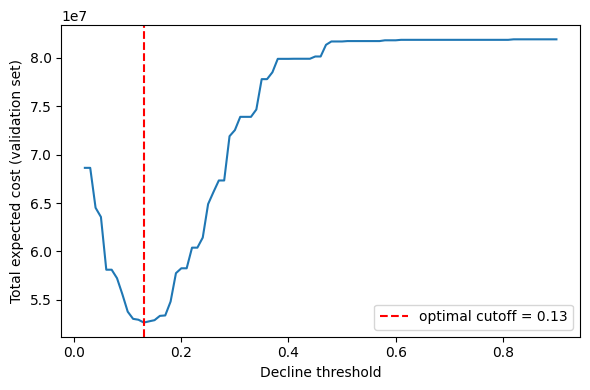

Chosen decline threshold: 0.130


In [10]:
from sklearn.metrics import confusion_matrix

COST_FALSE_NEGATIVE = 6000   # approve a loan that defaults: ~unrecovered principal
COST_FALSE_POSITIVE = 900    # decline a loan that would've performed: lost interest margin

thresholds = np.linspace(0.02, 0.90, 89)
costs = []
for t in thresholds:
    pred = (calibrated_model.predict_proba(X_val_enc)[:, 1] >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    costs.append(fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE)
costs = np.array(costs)
best_threshold = thresholds[np.argmin(costs)]

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(thresholds, costs)
ax.axvline(best_threshold, color='red', linestyle='--',
           label=f'optimal cutoff = {best_threshold:.2f}')
ax.set_xlabel('Decline threshold'); ax.set_ylabel('Total expected cost (validation set)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Chosen decline threshold: {best_threshold:.3f}")

Threshold chosen on validation, exactly like calibration — we still haven't touched
test for anything that could bias the threshold choice itself. Now the single, final,
fully out-of-sample report:

In [11]:
final_pred = (p_test_cal >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, final_pred).ravel()

print('=== Final OOT test performance at chosen operating point ===')
print(f"Threshold        : {best_threshold:.3f}")
print(f"Decline rate     : {(final_pred==1).mean():.1%}")
print(f"Approved bad rate: {y_test[final_pred==0].mean():.2%}  (vs. {y_test.mean():.2%} unfiltered)")
print(f"Confusion matrix : TN={tn} FP={fp} FN={fn} TP={tp}")
print(f"Estimated cost   : ${fn*COST_FALSE_NEGATIVE + fp*COST_FALSE_POSITIVE:,.0f}")

=== Final OOT test performance at chosen operating point ===
Threshold        : 0.130
Decline rate     : 44.8%
Approved bad rate: 8.09%  (vs. 14.88% unfiltered)
Confusion matrix : TN=45020 FP=30511 FN=3965 TP=9237
Estimated cost   : $51,249,900


**Sanity-check the corner cases.** If the cost-optimal threshold comes out near 0 or 1
(decline almost everyone, or almost no one), don't ship it on faith — that's usually a
sign the cost ratio and the model's discrimination power are mismatched (a highly
skewed cost ratio can dominate a weak model's ranking entirely), rather than a genuine
business-optimal policy. Re-check the cost inputs with the business owner, and confirm
the model's KS/decile behavior from earlier in this notebook actually supports acting
that aggressively before deploying it.

In [13]:
import json

joblib.dump(calibrated_model, 'xgb_calibrated_model.joblib')
with open('decision_config.json', 'w') as f:
    json.dump({
        'threshold': float(best_threshold),
        'cost_false_negative': COST_FALSE_NEGATIVE,
        'cost_false_positive': COST_FALSE_POSITIVE,
        'calibration_method': 'isotonic',
        'oot_test_roc_auc': float(roc_auc_score(y_test, p_test_cal)),
        'oot_test_ks': float(ks_2samp(p_test_cal[y_test==0], p_test_cal[y_test==1]).statistic),
    }, f, indent=2)

print('Saved xgb_calibrated_model.joblib and decision_config.json')

Saved xgb_calibrated_model.joblib and decision_config.json


## Summary

- Discrimination (ROC/PR-AUC, KS, decile rank-ordering) and calibration (reliability,
  Brier score) are separate questions — this project checks both, not just the one
  that's easier to compute.
- The model was calibrated on validation, using `FrozenEstimator` (or `cv='prefit'` on
  older scikit-learn) — never touching the OOT test set until the single final report.
- The accept/decline cutoff came from an explicit cost trade-off, not a generic
  F1-optimal or 0.5 default.
- Saved artifacts: `xgb_calibrated_model.joblib`, `decision_config.json`.

Next: **05 — explainability and a traditional points-based scorecard.**